# Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Business Problem Understanding

The e-commerce company wants to better understand customer purchasing behavior and identify valuable customer groups.

The main objectives of this project are:
- Identify high-value customers
- Improve customer retention
- Create targeted marketing campaigns
- Increase customer engagement
- Improve business decision-making using customer segmentation

RFM Analysis and K-Means Clustering are used to group customers based on:
- Recency of purchases
- Purchase frequency
- Customer spending behavior

These insights help businesses personalize offers, improve loyalty programs, and optimize marketing strategies.

# Load Dataset

In [2]:
df = pd.read_csv("data/ecommerce_data.csv")

df.head()

,InvoiceNo,StockCode,Description,Category,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,INV500000,P1022,Dark Chocolate Box,Grocery,1,2025-01-19 17:04:00,468.04,C10555,EIRE
1,INV500000,P1030,Sports Socks Pack,Apparel,1,2025-01-19 17:04:00,248.30,C10555,EIRE
2,INV500001,P1006,Wireless Mouse,Electronics,5,2025-10-17 18:50:00,729.12,C10422,India
3,INV500002,P1010,Protein Shaker,Fitness,2,2025-01-05 22:51:00,329.60,C10262,Netherlands
4,INV500002,P1022,Dark Chocolate Box,Grocery,1,2025-01-05 22:51:00,526.21,C10262,Netherlands


# Data Understanding

The dataset contains transaction-level purchase records from an e-commerce business.

## What Each Row Represents
Each row represents a single product purchased within a customer invoice or transaction.

## Important Columns

- InvoiceNo → Unique invoice number
- StockCode → Unique product identifier
- Description → Product description
- Category → Product category
- Quantity → Number of units purchased
- InvoiceDate → Date and time of purchase
- UnitPrice → Price per product unit
- CustomerID → Unique customer identifier
- Country → Customer country

## Business Use of Dataset

This dataset can help businesses:
- Analyze customer purchasing behavior
- Identify high-value customers
- Understand product performance
- Analyze sales by country
- Perform customer segmentation
- Improve marketing strategies

## Business Questions That Can Be Answered

- Which customers spend the most?
- Which products generate the highest revenue?
- Which countries contribute the most sales?
- Which customers purchase frequently?
- Which customers are inactive or at risk?

## Limitations of Dataset

The dataset does not include:
- Customer demographics
- Marketing campaign information
- Customer feedback
- Profit margins
- Product cost data

Therefore, profitability and demographic-based analysis cannot be performed.

# Data Cleaning

In [3]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nDuplicate Records:", df.duplicated().sum())

print("\nData Types:\n")
print(df.dtypes)

print("\nInvalid Quantities:", (df['Quantity'] <= 0).sum())

print("Invalid Prices:", (df['UnitPrice'] <= 0).sum())

Dataset Shape: (4395, 9)

Missing Values:

InvoiceNo        0
StockCode        0
Description     67
Category         0
Quantity         0
InvoiceDate      0
UnitPrice        0
CustomerID     208
Country          0
dtype: int64

Duplicate Records: 35

Data Types:

InvoiceNo       object
StockCode       object
Description     object
Category        object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID      object
Country         object
dtype: object

Invalid Quantities: 195
Invalid Prices: 69


In [4]:
df = df.drop_duplicates()

df = df.dropna(subset=['CustomerID', 'Description'])

df = df[
    (df['Quantity'] > 0) &
    (df['UnitPrice'] > 0)
]

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Revenue'] = df['Quantity'] * df['UnitPrice']

print("Cleaned Dataset Shape:", df.shape)

Cleaned Dataset Shape: (3848, 10)


### Cleaning Summary

The following cleaning steps were performed:
- Removed duplicate records
- Removed rows with missing customer IDs
- Removed rows with missing product descriptions
- Removed invalid quantities
- Removed invalid prices
- Converted InvoiceDate into datetime format
- Created Revenue column

# Feature Engineering

In [5]:
customer_data = df.groupby('CustomerID').agg({
    'Revenue': 'sum',
    'InvoiceNo': 'nunique',
    'Quantity': 'sum',
    'StockCode': 'nunique',
    'Country': 'first'
}).reset_index()

customer_data.columns = [
    'CustomerID',
    'TotalRevenue',
    'TotalPurchases',
    'TotalQuantity',
    'UniqueProducts',
    'Country'
]

customer_data['AverageOrderValue'] = (
    customer_data['TotalRevenue'] /
    customer_data['TotalPurchases']
)

customer_data.head()

,CustomerID,TotalRevenue,TotalPurchases,TotalQuantity,UniqueProducts,Country,AverageOrderValue
0,C10001,22885.81,3,63,8,India,7628.603333
1,C10003,12061.04,1,10,3,United Kingdom,12061.040000
2,C10004,10579.97,2,16,5,United Kingdom,5289.985000
3,C10005,14154.57,2,17,7,Germany,7077.285000
4,C10006,27389.29,3,27,8,India,9129.763333


### Feature Engineering Summary

The following customer-level features were created:

- TotalRevenue → Total amount spent by customer
- TotalPurchases → Number of unique purchases
- TotalQuantity → Total quantity purchased
- UniqueProducts → Number of unique products purchased
- AverageOrderValue → Average spending per purchase

These features help analyze customer purchasing behavior and customer value.

# RFM Analysis

RFM Analysis is used to evaluate customer value based on:

- Recency → How recently a customer made a purchase
- Frequency → How often a customer purchases
- Monetary → How much money a customer spends

RFM metrics help identify loyal customers, inactive customers, and high-value customer groups.

In [6]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (
        reference_date - x.max()
    ).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
}).reset_index()

rfm.columns = [
    'CustomerID',
    'Recency',
    'Frequency',
    'Monetary'
]

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,C10001,117,3,22885.81
1,C10003,33,1,12061.04
2,C10004,40,2,10579.97
3,C10005,297,2,14154.57
4,C10006,31,3,27389.29


In [7]:
customer_data = customer_data.merge(
    rfm,
    on='CustomerID'
)

customer_data.head()

,CustomerID,TotalRevenue,TotalPurchases,TotalQuantity,UniqueProducts,Country,AverageOrderValue,Recency,Frequency,Monetary
0,C10001,22885.81,3,63,8,India,7628.603333,117,3,22885.81
1,C10003,12061.04,1,10,3,United Kingdom,12061.040000,33,1,12061.04
2,C10004,10579.97,2,16,5,United Kingdom,5289.985000,40,2,10579.97
3,C10005,14154.57,2,17,7,Germany,7077.285000,297,2,14154.57
4,C10006,27389.29,3,27,8,India,9129.763333,31,3,27389.29


# Exploratory Data Analysis

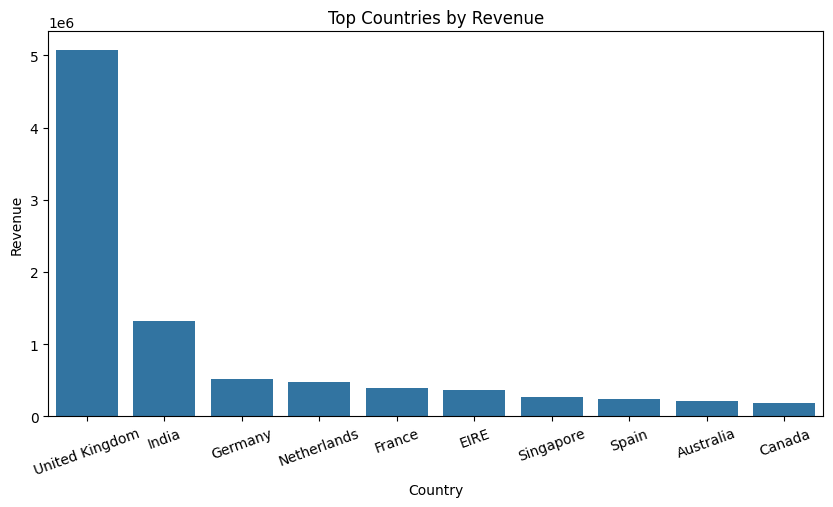

In [8]:
top_countries = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_countries.index,
    y=top_countries.values
)

plt.title('Top Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')

plt.xticks(rotation=20)

plt.show()

### Interpretation
Some countries contribute significantly higher revenue than others, indicating important regional customer markets for the business.

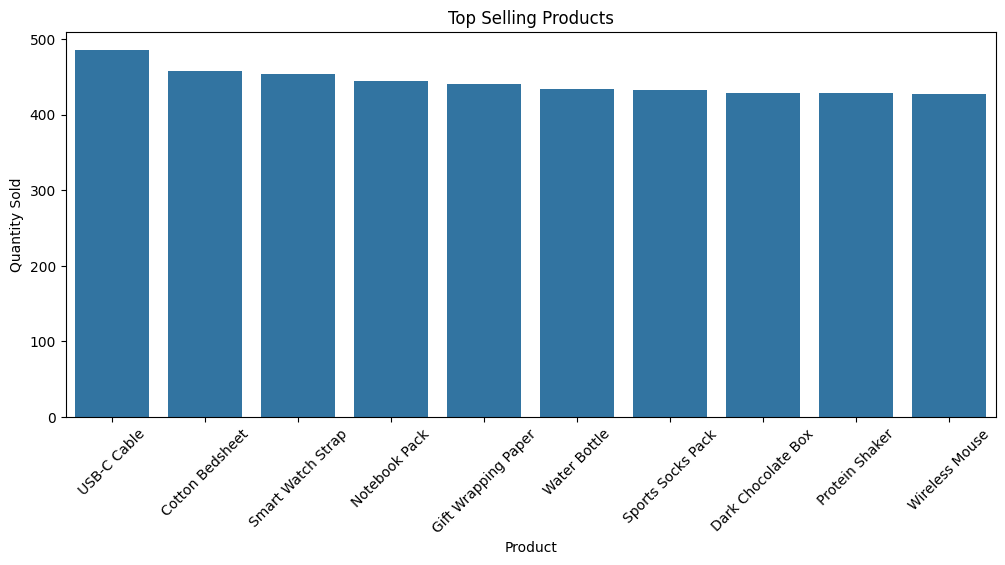

In [9]:
top_products = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_products.index,
    y=top_products.values
)

plt.title('Top Selling Products')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')

plt.xticks(rotation=45)

plt.show()

### Interpretation
Some products are purchased much more frequently than others, indicating strong customer demand and popular product categories.

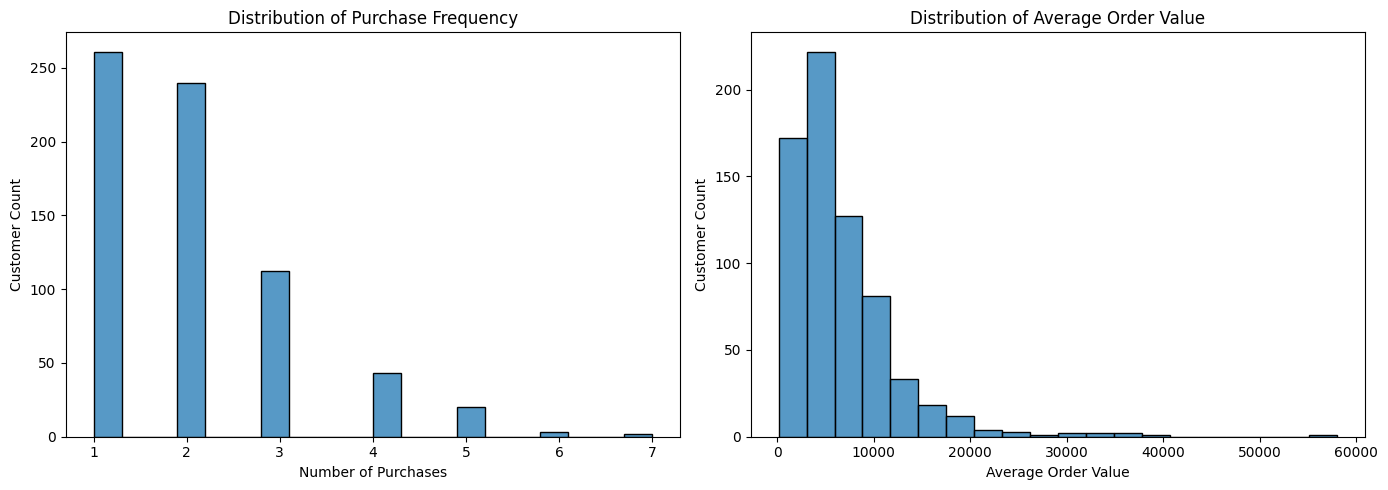

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(
    customer_data['TotalPurchases'],
    bins=20,
    ax=axes[0]
)

axes[0].set_title('Distribution of Purchase Frequency')
axes[0].set_xlabel('Number of Purchases')
axes[0].set_ylabel('Customer Count')

sns.histplot(
    customer_data['AverageOrderValue'],
    bins=20,
    ax=axes[1]
)

axes[1].set_title('Distribution of Average Order Value')
axes[1].set_xlabel('Average Order Value')
axes[1].set_ylabel('Customer Count')

plt.tight_layout()
plt.show()

### Interpretation
Customer purchasing frequency and order values vary significantly across customers. Some customers contribute substantially higher order values compared to the majority.

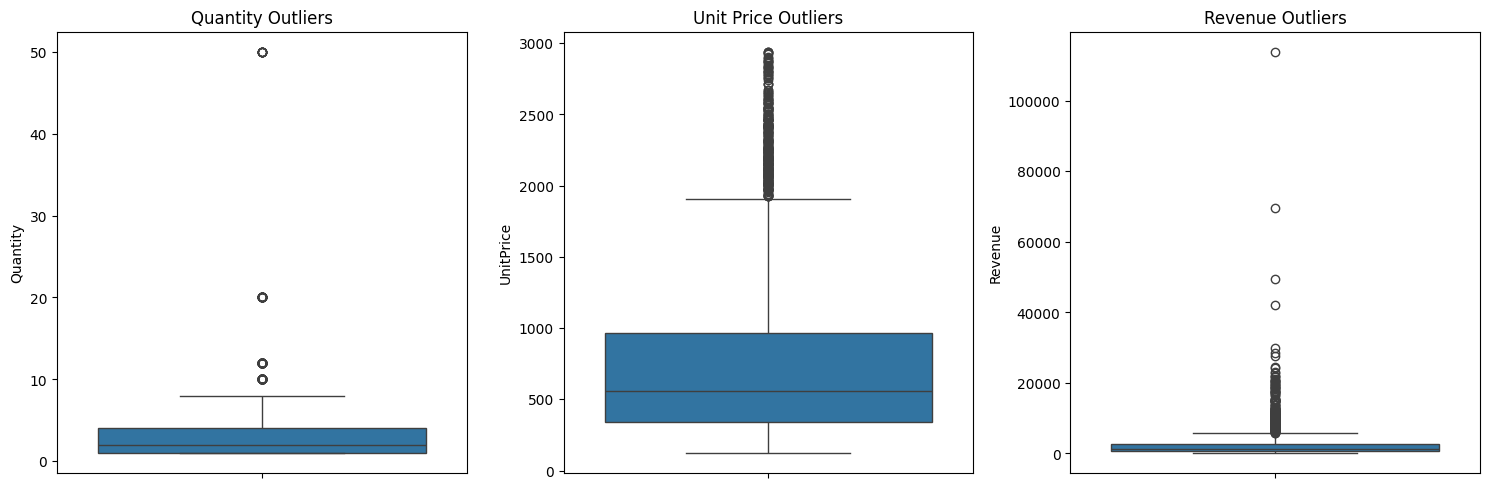

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.boxplot(y=df['Quantity'], ax=axes[0])
axes[0].set_title('Quantity Outliers')

sns.boxplot(y=df['UnitPrice'], ax=axes[1])
axes[1].set_title('Unit Price Outliers')

sns.boxplot(y=df['Revenue'], ax=axes[2])
axes[2].set_title('Revenue Outliers')

plt.tight_layout()
plt.show()

### Interpretation
Outliers are present in quantity, unit price, and revenue values. These may represent bulk purchases or premium customer transactions.

# Feature Scaling

RFM values have different ranges and scales.

Standardization is applied before clustering so that:
- All features contribute equally
- Distance calculations become more reliable
- K-Means clustering performs effectively

In [12]:
rfm_features = customer_data[[
    'Recency',
    'Frequency',
    'Monetary'
]]

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm_features
)

rfm_scaled[:5]

array([[-0.0800508 ,  0.88455416,  0.7537231 ],
       [-1.02072989, -0.93532917, -0.10768099],
       [-0.94233996, -0.02538751, -0.22554028],
       [ 1.93569011, -0.02538751,  0.05891611],
       [-1.04312701,  0.88455416,  1.11209709]])

In [13]:
pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary']
).head()

,Recency,Frequency,Monetary
0,-0.080051,0.884554,0.753723
1,-1.020730,-0.935329,-0.107681
2,-0.942340,-0.025388,-0.225540
3,1.935690,-0.025388,0.058916
4,-1.043127,0.884554,1.112097


# Customer Segmentation using K-Means

K-Means clustering is used to group customers with similar purchasing behavior based on RFM values.

The objective is to identify:
- High-value customers
- Medium-value customers
- Low-value or inactive customers

In [14]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

customer_data['Cluster'] = kmeans.fit_predict(
    rfm_scaled
)

customer_data.head()

,CustomerID,TotalRevenue,TotalPurchases,TotalQuantity,UniqueProducts,Country,AverageOrderValue,Recency,Frequency,Monetary,Cluster
0,C10001,22885.81,3,63,8,India,7628.603333,117,3,22885.81,1
1,C10003,12061.04,1,10,3,United Kingdom,12061.040000,33,1,12061.04,0
2,C10004,10579.97,2,16,5,United Kingdom,5289.985000,40,2,10579.97,0
3,C10005,14154.57,2,17,7,Germany,7077.285000,297,2,14154.57,2
4,C10006,27389.29,3,27,8,India,9129.763333,31,3,27389.29,1


In [15]:
cluster_summary = customer_data.groupby('Cluster')[[
    'Recency',
    'Frequency',
    'Monetary'
]].mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,66.761745,1.805369,9370.575973
1,75.277778,3.534722,30601.338750
2,225.146444,1.397490,8100.624435


### Cluster Interpretation

- Cluster 0:
  Medium-value customers with moderate purchasing frequency and spending.

- Cluster 1:
  High-value customers with high purchase frequency and strong spending behavior.

- Cluster 2:
  Lower-value or inactive customers with lower spending and higher recency values.

# Business Recommendations

- Provide loyalty rewards and premium offers to high-value customers in Cluster 1.
- Re-engage inactive customers in Cluster 2 using personalized discounts and targeted campaigns.
- Promote cross-selling opportunities for medium-value customers in Cluster 0.
- Focus retention strategies on customers with high purchase frequency and strong spending behavior.
- Use customer segmentation insights to improve personalized marketing campaigns.
- Monitor customer purchasing behavior regularly to identify changes in customer value.
- Develop targeted promotions for customers with declining activity levels.

# Conclusion

This project analyzed e-commerce customer purchasing behavior using RFM Analysis and K-Means Clustering.

Customer segmentation identified high-value, medium-value, and lower-value customer groups based on recency, frequency, and monetary spending behavior.

The analysis provides valuable insights that can help businesses:
- Improve customer retention
- Optimize marketing campaigns
- Increase customer engagement
- Personalize offers
- Improve long-term business revenue

Customer segmentation can support data-driven decision-making and improve overall business strategy.